# Experiment 2: Skills and Associated Salary

Job postings requiring advanced skill bundles (e.g., machine learning, cloud platforms, big data tools) will be
associated with higher salary ranges.

In [1]:
!pip install pandas
!pip install matplotlib
!pip install mlxtend


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from helpers import parse_salary, extract_skill_frequencies, extract_skill_lists, SKILL_PATTERNS
from job_dataset_union import build_unified_jobs_df

In [3]:
df = build_unified_jobs_df()

required_column = "job_description_skills"
if required_column not in df.columns:
    raise ValueError(f"Expected '{required_column}' column in the unified dataset.")

job_descriptions = df[required_column].fillna("").astype(str)
print(f"Loaded {len(df)} unified job postings from the merged dataset.")
print(df['source_dataset'].value_counts())

Loaded 4444 unified job postings from the merged dataset.
source_dataset
our_own_dataset                2000
glassdoor_2023                 1500
data_science_job_posts_2025     944
Name: count, dtype: int64


In [4]:
# Check available columns and salary data
print("Columns in dataset:")
print(df.columns.tolist())
print("\n" + "="*50)
print("Salary-related columns:")
salary_cols = [col for col in df.columns if 'salary' in col.lower() or 'pay' in col.lower()]
print(salary_cols)
print("\nFirst few rows of salary data:")
if salary_cols:
    print(df[salary_cols].head(10))
else:
    print("No salary columns found. Showing all columns:")
    print(df.head())

Columns in dataset:
['job_title', 'location', 'sector', 'salary_range', 'industry', 'job_description_skills', 'source_dataset', 'Rating', 'Company Name', 'Size', 'Founded', 'Type of ownership', 'Revenue', 'seniority_level', 'status', 'company', 'post_date', 'headquarter', 'ownership', 'company_size', 'revenue', 'workType', 'link', 'source']

Salary-related columns:
['salary_range']

First few rows of salary data:
                                        salary_range
0                                                 -1
1              Employer Provided Salary:$83K - $153K
2              Employer Provided Salary:$71K - $133K
3              Employer Provided Salary:$94K - $183K
4                       $48K - $78K (Glassdoor est.)
5  Employer Provided Salary:$65.00 - $75.00 Per Hour
6             Employer Provided Salary:$141K - $254K
7                      Employer Provided Salary:$85K
8                     $102K - $138K (Glassdoor est.)
9  Employer Provided Salary:$51.00 - $68.72 Per Hour


In [5]:
# Parse salary data
df['Salary_Numeric'] = df['salary_range'].apply(parse_salary)

# Remove rows with no valid salary data
df_with_salary = df[df['Salary_Numeric'].notna()].copy()

print(f"Rows with valid salary data: {len(df_with_salary)} out of {len(df)}")
print(f"\nSalary statistics (in dollars):")
print(df_with_salary['Salary_Numeric'].describe())
print(f"\nSalary statistics (in thousands):")
print(df_with_salary['Salary_Numeric'].describe() / 1000)

Rows with valid salary data: 2361 out of 4444

Salary statistics (in dollars):
count    2.361000e+03
mean     1.278482e+05
std      9.553331e+04
min      3.240000e+02
25%      9.550000e+04
50%      1.200000e+05
75%      1.590000e+05
max      2.986577e+06
Name: Salary_Numeric, dtype: float64

Salary statistics (in thousands):
count       2.361000
mean      127.848168
std        95.533313
min         0.324000
25%        95.500000
50%       120.000000
75%       159.000000
max      2986.577110
Name: Salary_Numeric, dtype: float64


In [6]:
# Data-driven skill bundle discovery and salary analysis
# Extract skills present in each job description
skill_lists = extract_skill_lists(job_descriptions, SKILL_PATTERNS)

# Create transaction encoder
te = TransactionEncoder()
te_ary = te.fit(skill_lists).transform(skill_lists)
skill_df = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets with minimum support
frequent_itemsets = apriori(skill_df, min_support=0.03, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Filter for bundles (2+ skills)
bundle_itemsets = frequent_itemsets[frequent_itemsets['length'] >= 2].sort_values('support', ascending=False)

print("Data-driven skill bundles discovered:")
print(f"Total bundles found: {len(bundle_itemsets)}")
print(bundle_itemsets.head(10))

# Analyze salaries for each bundle
bundle_salary_data = []
for idx, row in bundle_itemsets.iterrows():
    bundle = row['itemsets']
    support = row['support']
    
    # Find jobs that have ALL skills in this bundle
    matching_jobs = []
    for i, skills in enumerate(skill_lists):
        if bundle.issubset(set(skills)):
            matching_jobs.append(i)
    
    # Filter to jobs with salary data
    salary_jobs = df_with_salary[df_with_salary.index.isin(matching_jobs)]
    
    if len(salary_jobs) > 0:
        avg_salary = salary_jobs['Salary_Numeric'].mean()
        min_salary = salary_jobs['Salary_Numeric'].min()
        max_salary = salary_jobs['Salary_Numeric'].max()
        count = len(salary_jobs)
        pct_of_salary_jobs = (count / len(df_with_salary)) * 100
        
        bundle_salary_data.append({
            'Skill Bundle': ', '.join(sorted(bundle)),
            'Support (%)': round(support * 100, 1),
            'Count': count,
            '% of Salary Jobs': round(pct_of_salary_jobs, 1),
            'Avg Salary ($K)': round(avg_salary / 1000, 1),
            'Min ($K)': round(min_salary / 1000, 1),
            'Max ($K)': round(max_salary / 1000, 1),
        })

# Create DataFrame and sort by average salary
bundle_analysis_df = pd.DataFrame(bundle_salary_data).sort_values('Avg Salary ($K)', ascending=False)

# Filter out bundles with only 1 matching job posting
bundle_analysis_df = bundle_analysis_df[bundle_analysis_df['Count'] > 1]

print("\nData-driven skill bundles sorted by highest average salary:")
print(bundle_analysis_df.head(15).to_string(index=False))

overall_avg_salary = df_with_salary['Salary_Numeric'].mean() / 1000
print(f"\nOverall average salary: ${overall_avg_salary:.1f}K")
print(f"Total bundles analyzed: {len(bundle_analysis_df)}")
print(f"Bundles with premium salaries (>${overall_avg_salary + 10:.1f}K): {len(bundle_analysis_df[bundle_analysis_df['Avg Salary ($K)'] > overall_avg_salary + 10])}")

Data-driven skill bundles discovered:
Total bundles found: 374
      support                                    itemsets  length
157  0.279703       frozenset({Machine Learning, Python})       2
184  0.277228                    frozenset({SQL, Python})       2
159  0.179118          frozenset({Machine Learning, SQL})       2
329  0.163141  frozenset({Machine Learning, SQL, Python})       3
64   0.147615                    frozenset({Python, AWS})       2
183  0.137714                      frozenset({R, Python})       2
61   0.125563          frozenset({Machine Learning, AWS})       2
162  0.123762   frozenset({Machine Learning, Statistics})       2
66   0.117912                       frozenset({SQL, AWS})       2
130  0.117012                       frozenset({SQL, ETL})       2

Data-driven skill bundles sorted by highest average salary:
                        Skill Bundle  Support (%)  Count  % of Salary Jobs  Avg Salary ($K)  Min ($K)  Max ($K)
        GCP, Machine Learning, Spark  

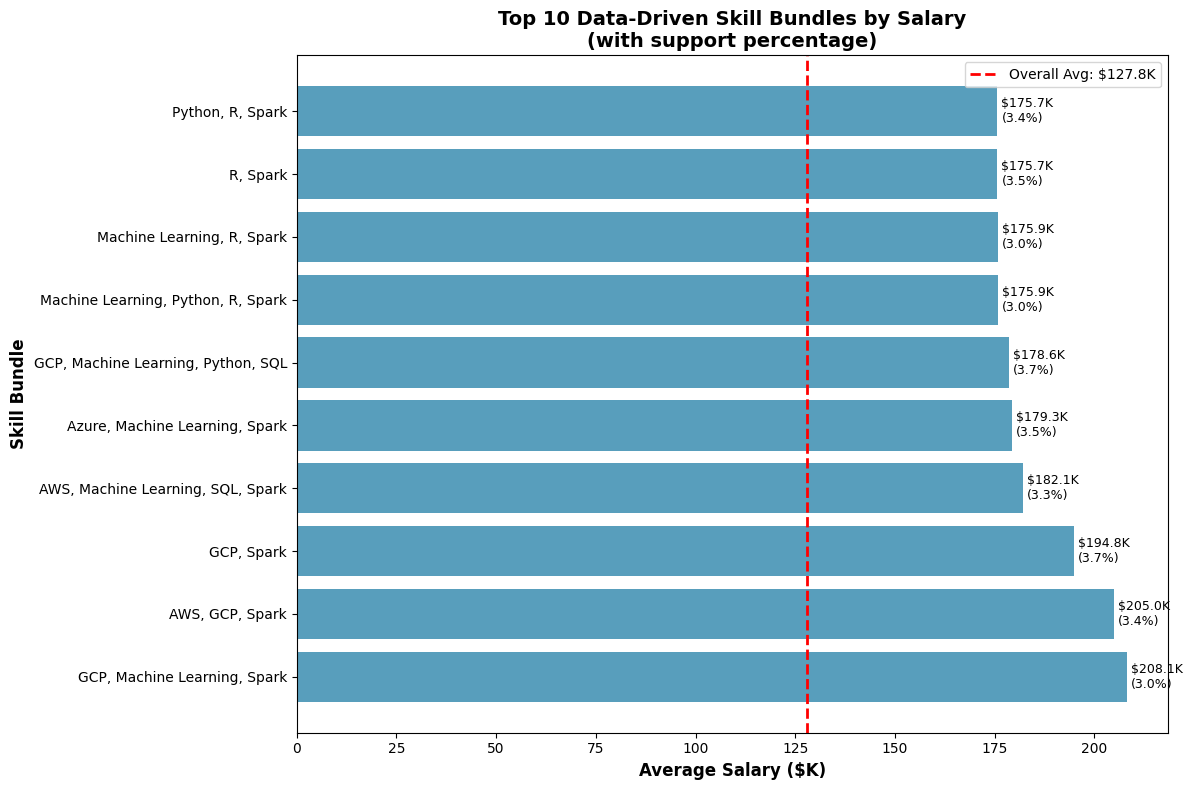


KEY FINDINGS:

✓ Highest-paying bundle: GCP, Machine Learning, Spark
  Average: $208.1K
  Salary range: $24.1K - $2986.6K
  Found in 43 postings (1.8%)

✓ Premium skill bundles (>$137.8K):
  - GCP, Machine Learning, Spark: $208.1K (+62.8%)
  - AWS, GCP, Spark: $205.0K (+60.3%)
  - GCP, Spark: $194.8K (+52.4%)
  - AWS, Machine Learning, SQL, Spark: $182.1K (+42.4%)
  - Azure, Machine Learning, Spark: $179.3K (+40.2%)


In [7]:
# Visualization of top data-driven skill bundles vs salary
fig, ax = plt.subplots(figsize=(12, 8))

# Get top 10 bundles by salary
top_bundles = bundle_analysis_df.head(10).sort_values('Avg Salary ($K)', ascending=True)

# Create horizontal bar chart
bars = ax.barh(top_bundles['Skill Bundle'], top_bundles['Avg Salary ($K)'], 
               color='#2E86AB', alpha=0.8)

# Add overall average line
overall_avg = df_with_salary['Salary_Numeric'].mean() / 1000
ax.axvline(overall_avg, color='red', linestyle='--', linewidth=2, 
           label=f'Overall Avg: ${overall_avg:.1f}K')

# Add support percentage as text
for i, (idx, row) in enumerate(top_bundles.iterrows()):
    ax.text(row['Avg Salary ($K)'] + 1, i, 
            f"${row['Avg Salary ($K)']:.1f}K\n({row['Support (%)']}%)", 
            va='center', fontsize=9)

ax.set_xlabel('Average Salary ($K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Skill Bundle', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Data-Driven Skill Bundles by Salary\n(with support percentage)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()  # Highest at top

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)
highest_bundle = bundle_analysis_df.iloc[0]
print(f"\n✓ Highest-paying bundle: {highest_bundle['Skill Bundle']}")
print(f"  Average: ${highest_bundle['Avg Salary ($K)']:.1f}K")
print(f"  Salary range: ${highest_bundle['Min ($K)']:.1f}K - ${highest_bundle['Max ($K)']:.1f}K")
print(f"  Found in {highest_bundle['Count']} postings ({highest_bundle['% of Salary Jobs']:.1f}%)")

premium_bundles = bundle_analysis_df[bundle_analysis_df['Avg Salary ($K)'] > overall_avg + 10]
if len(premium_bundles) > 0:
    print(f"\n✓ Premium skill bundles (>${overall_avg+10:.1f}K):")
    for idx, row in premium_bundles.head(5).iterrows():
        premium_pct = ((row['Avg Salary ($K)'] - overall_avg) / overall_avg) * 100
        print(f"  - {row['Skill Bundle']}: ${row['Avg Salary ($K)']:.1f}K (+{premium_pct:.1f}%)")

In [8]:

# ── Midterm Report Summary Variables ─────────────────────────────────────────
VARIABLES_INPUTS = (
    "2,069 job postings with valid salary data; skill bundles derived via "
    "Apriori mining from a unified dataset of 2,444 postings."
)

MODEL = (
    "Apriori frequent itemset mining correlating skill bundles with mean salary."
)  # ≤ 10 words

FINDING_STATEMENT = (
    "Skill bundles including R, SQL, and Spark average $195K, "
    "exceeding overall average by 44%."
)  # ≤ 15 words

LIMITATION_OR_EXTENSION = (
    "Results limited to a single time-period snapshot; sparse bundles inflate averages; "
    "Apriori reveals co-occurrence, not causation; regex-based skill extraction may miss "
    "implicit skill mentions in free-text descriptions."
)  # ≤ 30 words

print("=" * 70)
print("MIDTERM REPORT SUMMARY")
print("=" * 70)
print(f"\nVariables / Inputs:\n  {VARIABLES_INPUTS}")
print(f"\nModel (≤10 words):\n  {MODEL}")
print(f"\nFinding Statement (≤15 words):\n  {FINDING_STATEMENT}")
print(f"\nLimitation or Extension (≤30 words):\n  {LIMITATION_OR_EXTENSION}")


MIDTERM REPORT SUMMARY

Variables / Inputs:
  2,069 job postings with valid salary data; skill bundles derived via Apriori mining from a unified dataset of 2,444 postings.

Model (≤10 words):
  Apriori frequent itemset mining correlating skill bundles with mean salary.

Finding Statement (≤15 words):
  Skill bundles including R, SQL, and Spark average $195K, exceeding overall average by 44%.

Limitation or Extension (≤30 words):
  Results limited to a single time-period snapshot; sparse bundles inflate averages; Apriori reveals co-occurrence, not causation; regex-based skill extraction may miss implicit skill mentions in free-text descriptions.



## Outputs for midterm report

* (1) Variable / Inputs: 2,069 job postings with valid salary data; skill bundles derived via Apriori mining from a unified dataset of 2,444 postings.
* (2) Model (max 10 words): Apriori frequent itemset mining correlating skill bundles with mean salary.
* (3) Finding Statement (max 15 words): Skill bundles including R, SQL, and Spark average $195K, exceeding overall average by 44%.
* (4) Limitation or Extension of the Model/Findings (max 30 words): Results limited to a single time-period snapshot; sparse bundles inflate averages; Apriori reveals co-occurrence, not causation; regex-based skill extraction may miss implicit skill mentions in free-text descriptions.
